# Week 2: Data Cleaning and Preprocessing

## Cardiovascular Disease Prediction using Machine Learning

### Objectives
- Handle missing values
- Check duplicate records
- Detect and handle outliers
- Encode categorical variables
- Normalize/Scale numerical features
- Prepare data for Machine Learning models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("cardio_train.csv", sep=";")

In [5]:
df.head()#display first 5

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
print("Dataset Shape:", df.shape) #dataset dimensions

Dataset Shape: (70000, 13)


## 1. Checking Missing Values

In [25]:
df.isnull().sum() 

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

## 2. Checking Duplicate Records

In [26]:
duplicate_count = df.duplicated().sum() #to check for duplicate once
print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


## 3. Fix Data Types

In [27]:
df.info()    #to get the datatype of all columns,not null values,total rows and cols,and their cols name 

<class 'pandas.core.frame.DataFrame'>
Index: 64502 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           64502 non-null  int64  
 1   age          64502 non-null  float64
 2   gender       64502 non-null  int64  
 3   height       64502 non-null  float64
 4   weight       64502 non-null  float64
 5   ap_hi        64502 non-null  float64
 6   ap_lo        64502 non-null  float64
 7   cholesterol  64502 non-null  int64  
 8   gluc         64502 non-null  int64  
 9   smoke        64502 non-null  int64  
 10  alco         64502 non-null  int64  
 11  active       64502 non-null  int64  
 12  cardio       64502 non-null  int64  
dtypes: float64(5), int64(8)
memory usage: 6.9 MB


## 5. Handling Outliers Using IQR Method

In [28]:
Q1 = df['ap_hi'].quantile(0.25)
Q3 = df['ap_hi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: 0.0
Upper Limit: 1.0


In [29]:
# Remove outliers from ap_hi
df = df[(df['ap_hi'] >= lower) & (df['ap_hi'] <= upper)]

print("Dataset Shape after removing ap_hi outliers:", df.shape)

Dataset Shape after removing ap_hi outliers: (64502, 13)


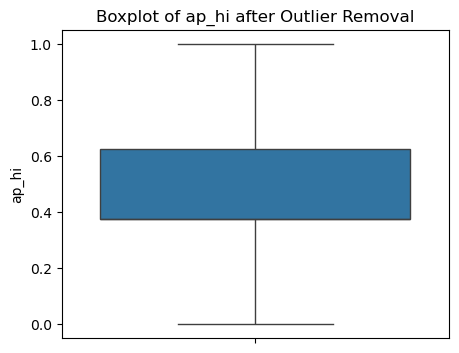

In [30]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['ap_hi'])
plt.title("Boxplot of ap_hi after Outlier Removal")
plt.show()

In [31]:
Q1 = df['ap_lo'].quantile(0.25)
Q3 = df['ap_lo'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: 0.0
Upper Limit: 1.0


In [32]:
# Remove outliers from ap_lo
df = df[(df['ap_lo'] >= lower) & (df['ap_lo'] <= upper)]

print("Dataset Shape after removing ap_lo outliers:", df.shape)

Dataset Shape after removing ap_lo outliers: (64502, 13)


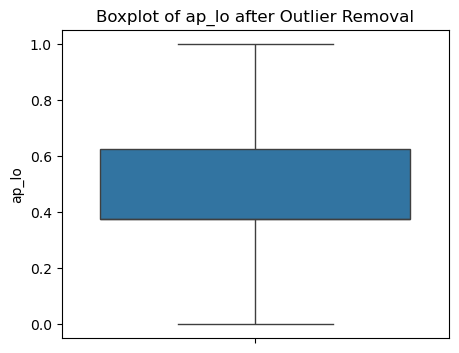

In [33]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['ap_lo'])
plt.title("Boxplot of ap_lo after Outlier Removal")
plt.show()

In [34]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.586121,2,0.579487,0.269841,0.250,0.375,1,1,0,0,1,0
1,1,0.728878,1,0.517949,0.391534,0.625,0.625,3,1,0,0,1,1
2,2,0.622219,1,0.564103,0.280423,0.500,0.125,3,1,0,0,0,1
3,3,0.526218,2,0.584615,0.375661,0.750,0.875,1,1,0,0,1,1
5,8,0.860044,1,0.492308,0.296296,0.375,0.375,2,2,0,0,0,0


## 6. Feature Scaling

In [35]:
# Separate features and target variable
X = df.drop('cardio', axis=1)   #x-->features    y-->target variable
y = df['cardio']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (64502, 12)
Target Shape: (64502,)


In [36]:
scaler = StandardScaler()     #z=(x−mean)/standard deviation    Mean ≈ 0    Standard Deviation ≈ 1
X_scaled = scaler.fit_transform(X)    #fit()-->Calculates the mean and standard deviation   , transform()-->Uses those values to scale
print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

## 7. Encoding Categorical Variables

In [37]:
print("Encoding is not required because categorical columns are already represented using numeric values.")    # categorial--> numerical data

Encoding is not required because categorical columns are already represented using numeric values.


In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()        #featurescaling--> to bring numerical data to common range
cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']   #-->list of numerical columns
df[cols] = scaler.fit_transform(df[cols])    #fit--> min max of each col  , transform()-->Converts every value to a number between 0 and 1
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.586121,2,0.579487,0.269841,0.250,0.375,1,1,0,0,1,0
1,1,0.728878,1,0.517949,0.391534,0.625,0.625,3,1,0,0,1,1
2,2,0.622219,1,0.564103,0.280423,0.500,0.125,3,1,0,0,0,1
3,3,0.526218,2,0.584615,0.375661,0.750,0.875,1,1,0,0,1,1
5,8,0.860044,1,0.492308,0.296296,0.375,0.375,2,2,0,0,0,0


## 9. Save the Preprocessed Dataset

In [39]:
df.to_csv("cardio_train_cleaned.csv", index=False)
print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!
